## Первостепенная задача - обработать данные датасета к дальнейшим манипуляциям с ним.

Преимущественно данные должны быть в числовом формате (int, float), а любые уточняющие записи вынесены в название столбца \ описание датасета. Ячейки должны быть проверены на корректность записи в них. Все категориальные данные должны быть преобразованы в целочисленные, соответствие категориальные-целочисленные сохранены (в случае биномиального распределения данных, можно привести данные к типу bool, в ином случае - целочисленные).

## Второстепенная задача - ознакомление и тренировка в использовании пакета scikit-learn для машинного обучения на предобработанных данных.

На основе полностью заполненных записей датасета обучить наиболее подходящую регрессионную модель для заполнения колонки целевой переменной (Rating), проанализировать насколько хорошо обучена модель.

## Третьестепенная задача - проанализировать целевые метрики на основе обработанного датасета



In [2]:
import pandas as pd
import numpy as np
import re
from collections import defaultdict
import matplotlib.pyplot as plt

Импортируем датасет с Kaggle, собранные данные с Amazon

In [3]:
dataset = pd.read_csv('../data/amazon_sales_data_uncleaned.csv', encoding='utf-8')
dataset.head(3)

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14


In [4]:
dataset.shape

(42675, 16)

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Title                     42675 non-null  object
 1   Rating                    41651 non-null  object
 2   Number_of_reviews         41651 non-null  object
 3   bought_in_last_month      39458 non-null  object
 4   Current/discounted_price  30926 non-null  object
 5   Price_on_variant          42675 non-null  object
 6   Listed_price              42675 non-null  object
 7   is_best_seller            42675 non-null  object
 8   is_sponsored              42675 non-null  object
 9   is_couponed               42675 non-null  object
 10  buy_box_availability      28022 non-null  object
 11  delivery_details          30955 non-null  object
 12  sustainability_badges     3408 non-null   object
 13  image_url                 42675 non-null  object
 14  product_url           

In [6]:
dataset.describe()

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
count,42675,41651,41651,39458,30926,42675,42675,42675,42675,42675,28022,30955,3408,42675,40606,42675
unique,8808,31,4413,59,2576,3466,911,12,2,42,1,298,16,8038,40606,331
top,"Duracell Coppertop 9V Battery, 6 Count (Pack o...",4.6 out of 5 stars,25,100+ bought in past month,29.99,basic variant price: nan,No Discount,No Badge,Organic,No Coupon,Add to cart,"Delivery Mon, Sep 1",Small Business,https://m.media-amazon.com/images/I/51Xr76m2WL...,/Lorex-8-Channel-Security-Outdoor-Cameras/dp/B...,25-08-2025 11:07
freq,744,6151,626,8801,825,21031,30364,40814,35664,40727,28022,6189,1341,1461,1,180


In [7]:
dataset.isna().sum()

Title                           0
Rating                       1024
Number_of_reviews            1024
bought_in_last_month         3217
Current/discounted_price    11749
Price_on_variant                0
Listed_price                    0
is_best_seller                  0
is_sponsored                    0
is_couponed                     0
buy_box_availability        14653
delivery_details            11720
sustainability_badges       39267
image_url                       0
product_url                  2069
collected_at                    0
dtype: int64

Исходя из выведенных данных видим, что, скорее всего, данные были собраны парсером страниц. Это важное понимание даст возможность иначе интерпретировать данные датасета, ибо null в некоторых подобных случаях может значить отсутствие, то есть False (так как парсер не нашел например кнопки заказать, т.е. этот продукт недоступен).

----------------------------------------------------------------------------------------

наличие или отсутствие картинки товара так же может сказываться на продажах

In [8]:
data = dataset.copy()
data.loc[data['image_url'].isna(), 'image_url'] = 0
data.loc[data['image_url'].notna(), 'image_url'] = 1

data = data.rename(columns={'image_url': 'have_image_url'})
data = data.drop(columns='product_url')

data.head(3)

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,have_image_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,1,21-08-2025 11:14
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,1,21-08-2025 11:14
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,1,21-08-2025 11:14


Видим из структуры столбца Rating, оценку продукта пользователями по 5-балльной шкале, для дальнейшей работы с датасетом гораздо полезнее будет извлечь сам рейтинг формата X.XX и преобразовать в тип целого числа с плавающей запятой, исходя из формы самой оценки достаточно очевидным становится, что максимальная оценка - 5 баллов

In [9]:
converted_rating = data['Rating'].str.extract(r'(\d+(?:\.\d+)?)').rename(columns={0: 'Rating'}).astype(np.float64)
data['Rating'] = converted_rating['Rating']
data.head(3)

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,have_image_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,1,21-08-2025 11:14
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,1,21-08-2025 11:14
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,"3,044",2K+ bought in past month,314,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,1,21-08-2025 11:14


В столбце Number_of_reviews, казалось бы, уже тип данных - целочисленный с плавающей запятой, на самом деле это строка вида 'X,XXX', выходов для инициализации строки несколько, либо знать, что в python плавающая запятая обозначается '.', либо проверить любое из значений этой строки на тип, на предмет 'object' или 'str'

In [10]:
data['Number_of_reviews'] = data['Number_of_reviews'].str.replace(',', '').astype(np.float64)

In [11]:
data['Number_of_reviews'].dtypes, data['Number_of_reviews'][:3], data['Number_of_reviews'].isna().sum()

(dtype('float64'),
 0     375.0
 1    2457.0
 2    3044.0
 Name: Number_of_reviews, dtype: float64,
 np.int64(1024))

Видим столбец bought_in_last_month, очень полезная статистика, так же можем преобразовать в столбец типа целового числа с плавающей запятой, заменив логику самого столбца (в название перенести тот факт, что покупок было сделано больше, чем показывает значение в столбце), заменив обозначение 'K', что в англоязычной среде значит тысячи, на '000'

In [12]:
interm_boughts = data['bought_in_last_month'].str.split('+').str[0]
interm_boughts = pd.to_numeric(interm_boughts.str.replace('K', '000'), errors='coerce')
interm_boughts[:3]

0     300.0
1    6000.0
2    2000.0
Name: bought_in_last_month, dtype: float64

In [13]:
data['bought_in_last_month'] = interm_boughts
data['bought_in_last_month'] = data['bought_in_last_month']
data = data.rename(columns={'bought_in_last_month': 'bought_over_then_in_last_month'})
data.head(3)

,Title,Rating,Number_of_reviews,bought_over_then_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,have_image_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,1,21-08-2025 11:14
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,1,21-08-2025 11:14
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,1,21-08-2025 11:14


In [14]:
data['Current/discounted_price'] = pd.to_numeric(data['Current/discounted_price'], errors='coerce').astype(np.float64)

In [15]:
converted_listed_price = pd.to_numeric(data['Listed_price'].str.split('$').str[-1], errors='coerce')
data['Listed_price'] = converted_listed_price
data = data.rename(columns={'Listed_price': 'Listed_price, $'})
data.head(3)

,Title,Rating,Number_of_reviews,bought_over_then_in_last_month,Current/discounted_price,Price_on_variant,"Listed_price, $",is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,have_image_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,basic variant price: 2.4GHz,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,1,21-08-2025 11:14
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,basic variant price: nan,15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,1,21-08-2025 11:14
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,basic variant price: nan,349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,1,21-08-2025 11:14


In [16]:
data['is_best_seller'].value_counts()

is_best_seller
No Badge             40814
Amazon's               744
Limited time deal      409
Best Seller            275
Save 30%               125
Ends in                 97
Save 10%                61
Save 18%                57
Save 17%                51
Save 12%                26
Save 9%                 14
Save 77%                 2
Name: count, dtype: int64

Парсер инициализировал все бейджи на продуктах, как продукт-best_seller, так как на месте бейджа располагаются и скидки и бейдж Amazon's choice. Было принято решение реальные бестселлеры (как оказалось в количестве 275 штук) обозначить за 1, все остальные продукты без конкретно этого бейджа обозначить за 0 (то есть не best_seller) 

In [17]:
converted_best_sellers = data['is_best_seller'].str.contains('Best Seller', na=False).astype(np.int32)
data['is_best_seller'] = converted_best_sellers
data['is_best_seller'][:3]

0    0
1    0
2    0
Name: is_best_seller, dtype: int32

In [18]:
converted_sponsored = data['is_sponsored'].str.contains('Sponsored', na=False).astype(np.int32)
data['is_sponsored'] = converted_sponsored
data.head(3)

,Title,Rating,Number_of_reviews,bought_over_then_in_last_month,Current/discounted_price,Price_on_variant,"Listed_price, $",is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,have_image_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,basic variant price: 2.4GHz,159.00,0,1,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,1,21-08-2025 11:14
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,basic variant price: nan,15.99,0,1,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,1,21-08-2025 11:14
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,basic variant price: nan,349.00,0,1,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,1,21-08-2025 11:14


In [19]:
data['is_couponed'] = data['is_couponed'].str.split('  ').str[0]
data['is_couponed'].value_counts()

is_couponed
No Coupon       40727
Save $16.00       438
Save 15%          398
Save 10%          218
Save 5%           191
Save 50%          123
Save $11.00       120
Save $100.00       97
Save 40%           96
Save $25.00        65
Save $30.00        49
Save $69.00        31
Save 8%            18
Save $10.00        14
Save $33.00        13
Save $20.00         9
Save 20%            9
Save $18.00         8
Save $45.00         5
Save $15.00         5
Save $4.00          4
Save $1.00          4
Save 25%            4
Save $12.00         3
Save $2.00          3
Save 6%             2
Save $50.00         2
Save $5.00          2
Save $60.00         2
Save $40.00         2
Save $8.00          2
Save $1.50          2
Save $0.33          1
Save $133.00        1
Save 7%             1
Save 30%            1
Save $3.00          1
Save $29.00         1
Save $13.00         1
Save $90.00         1
Save $120.00        1
Name: count, dtype: int64

Видим сложный столбец is_couponed в точки зрения формата записи данных, в нем есть и пропуски, и скидки в процентном эквиваленте, и скидки в денежном эквиваленте.

Было принято решение разбить этот столбец на 2 столбца: в первом (dollars_coupon) содержится число типа целового числа с плавающей запятой - сколько конкретной суммы уйдет ввиду скидки; во втором (discount_coupon) содержится число типа целового числа с плавающей запятой [0, 1] - доля скидки от полной стоимости

In [20]:
data['is_couponed'].value_counts()

coup_extraction = data['is_couponed'].str.extract(r'(\$?\s*\d+(?:\.\d+)?\s*%?)')\
                                        .fillna('No Coupon').rename(columns={0: 'is_couponed'})

discount_coupons = coup_extraction['is_couponed'].str.extract(r'(\d+(?:\.\d+)?)\s*%')\
                                                .fillna(0).rename(columns={0: 'coupon_discount'})\
                                                .astype(np.float64) / 100

dollars_coupons = coup_extraction['is_couponed'].str.extract(r'\$\s*(\d+(?:\.\d+)?)')\
                                                .fillna(0).rename(columns={0: 'dollars_coupon'})\
                                                .astype(np.float64)

dollars_coupons.tail(5), discount_coupons.head(3)

(       dollars_coupon
 42670             0.0
 42671            25.0
 42672             0.0
 42673             0.0
 42674             0.0,
    coupon_discount
 0             0.15
 1             0.00
 2             0.00)

In [21]:
data['dollars_coupon'] = dollars_coupons
data['discount_coupon'] = discount_coupons
data.head(3)

,Title,Rating,Number_of_reviews,bought_over_then_in_last_month,Current/discounted_price,Price_on_variant,"Listed_price, $",is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,have_image_url,collected_at,dollars_coupon,discount_coupon
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,basic variant price: 2.4GHz,159.00,0,1,Save 15%,Add to cart,"Delivery Mon, Sep 1",Carbon impact,1,21-08-2025 11:14,0.0,0.15
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,basic variant price: nan,15.99,0,1,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,1,21-08-2025 11:14,0.0,0.00
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,basic variant price: nan,349.00,0,1,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,1,21-08-2025 11:14,0.0,0.00


In [22]:
data['buy_box_availability'].value_counts()

buy_box_availability
Add to cart    28022
Name: count, dtype: int64

Как раз здесь пригодится понимание того, что данные сформированы парсером, то есть, если есть кнопка тележки, значит товар может быть куплен, то есть он доступен, если же картинки тележки нет, значит товар недоступен к покупке (распродан, снят с производства и т.п.). Поэтому тип данных приведен к формату bool (да\нет).

In [23]:
data['buy_box_availability'].isna().sum()

np.int64(14653)

In [24]:
data[data['buy_box_availability'].isna()].head(3)

,Title,Rating,Number_of_reviews,bought_over_then_in_last_month,Current/discounted_price,Price_on_variant,"Listed_price, $",is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,have_image_url,collected_at,dollars_coupon,discount_coupon
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,NaN,basic variant price: $162.24,NaN,1,0,No Coupon,NaN,NaN,NaN,1,21-08-2025 11:14,0.0,0.0
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,NaN,basic variant price: $72.74,NaN,0,0,No Coupon,NaN,NaN,NaN,1,21-08-2025 11:14,0.0,0.0
5,Texas Instruments TI-84 Plus CE Color Graphing...,4.6,44522.0,100000.0,NaN,basic variant price: $99.95,NaN,1,0,No Coupon,NaN,NaN,NaN,1,21-08-2025 11:14,0.0,0.0


In [25]:
data['buy_box_availability'] = data['buy_box_availability'].notna().astype(int)
data = data.rename(columns={'buy_box_availability': 'is_available'})
data.head(3)

,Title,Rating,Number_of_reviews,bought_over_then_in_last_month,Current/discounted_price,Price_on_variant,"Listed_price, $",is_best_seller,is_sponsored,is_couponed,is_available,delivery_details,sustainability_badges,have_image_url,collected_at,dollars_coupon,discount_coupon
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,basic variant price: 2.4GHz,159.00,0,1,Save 15%,1,"Delivery Mon, Sep 1",Carbon impact,1,21-08-2025 11:14,0.0,0.15
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,basic variant price: nan,15.99,0,1,No Coupon,1,"Delivery Fri, Aug 29",NaN,1,21-08-2025 11:14,0.0,0.00
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,basic variant price: nan,349.00,0,1,No Coupon,1,"Delivery Mon, Sep 1",NaN,1,21-08-2025 11:14,0.0,0.00


В столбце информации о доставке - строка, из которой можно извлечь день недели (далее преобразовать в номер дня недели типа целого числа) и дату (поскольку специфика парсера - продукты за 2025 год, можем получить полную дату доставки), приведя к типу datetime.

In [26]:
delivery_data = data['delivery_details'].str.extract(r'(\w+)\s*\,\s*(\w+\s*\d+)', flags=re.IGNORECASE)\
                            .rename(columns={0: 'delivery_day',
                                             1: 'delivery_date'})

day_num = {'Mon': 1,
           'Tue': 2,
           'Wed': 3,
           'Thu': 4,
           'Fri': 5,
           'Sat': 6,
           'Sun': 7}

delivery_data['delivery_day'] = delivery_data['delivery_day'].map(day_num).fillna(0).astype(np.int32)

delivery_data['delivery_date'] = pd.to_datetime(
    delivery_data['delivery_date'].astype(str) + ' 2025',
    format='%b %d %Y',
    errors='coerce'
)

delivery_data.head(5)

,delivery_day,delivery_date
0,1,2025-09-01
1,5,2025-08-29
2,1,2025-09-01
3,0,NaT
4,0,NaT


In [27]:
data['delivery_details'] = delivery_data['delivery_day']
data = data.rename(columns={'delivery_details': 'delivery_day_number'})

data['delivery_date'] = delivery_data['delivery_date']

In [28]:
data['collected_at'] = pd.to_datetime(data['collected_at'])
data['collected_at']

C:\Users\Max-W10\AppData\Local\Temp\ipykernel_21624\829135409.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['collected_at'] = pd.to_datetime(data['collected_at'])


0       2025-08-21 11:14:00
1       2025-08-21 11:14:00
2       2025-08-21 11:14:00
3       2025-08-21 11:14:00
4       2025-08-21 11:14:00
                ...        
42670   2025-08-30 19:56:00
42671   2025-08-30 19:56:00
42672   2025-08-30 19:56:00
42673   2025-08-30 19:56:00
42674   2025-08-30 19:56:00
Name: collected_at, Length: 42675, dtype: datetime64[ns]

In [29]:
data.head(3)

,Title,Rating,Number_of_reviews,bought_over_then_in_last_month,Current/discounted_price,Price_on_variant,"Listed_price, $",is_best_seller,is_sponsored,is_couponed,is_available,delivery_day_number,sustainability_badges,have_image_url,collected_at,dollars_coupon,discount_coupon,delivery_date
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,basic variant price: 2.4GHz,159.00,0,1,Save 15%,1,1,Carbon impact,1,2025-08-21 11:14:00,0.0,0.15,2025-09-01
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,basic variant price: nan,15.99,0,1,No Coupon,1,5,NaN,1,2025-08-21 11:14:00,0.0,0.00,2025-08-29
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,basic variant price: nan,349.00,0,1,No Coupon,1,1,NaN,1,2025-08-21 11:14:00,0.0,0.00,2025-09-01


Достаточно непростое решение касательно марок качества, по сути своей они значат совершенно разное, и покупателя может завлечь как содержимое марки, так и просто ее наличие. Было принято решение перевести категориальные данные в формат номер категории для удобства дальнейшей обработки.

In [30]:
data['sustainability_badges'] = data['sustainability_badges'].fillna('No badge')
data['sustainability_badges'].value_counts()

sustainability_badges
No badge                          39267
Small Business                     1341
Carbon impact                       769
Works with Alexa                    425
Energy efficiency                   262
Alexa Built-in                      184
Manufacturing practices             148
Energy efficiency +3 more           121
Energy efficiency +1 more            93
Forestry practices                   18
Safer chemicals +2 more              18
Recycled materials                    7
Recycled materials +2 more            7
Safer chemicals +1 more               6
Recycled materials +3 more            4
Made in Italy                         4
1 sustainability certification        1
Name: count, dtype: int64

In [31]:
def category_transform(vector: pd.Series) -> pd.Series:
    uniques = vector.unique()
    return pd.Series(
        np.arange(0, len(uniques), 1),
        index=uniques
    )

label_enc = category_transform(data['sustainability_badges'])
label_enc['Carbon impact'], label_enc['No badge'] = label_enc['No badge'], label_enc['Carbon impact']
label_enc = label_enc.sort_values()
label_enc

No badge                           0
Carbon impact                      1
Energy efficiency                  2
Safer chemicals +1 more            3
Small Business                     4
1 sustainability certification     5
Works with Alexa                   6
Manufacturing practices            7
Forestry practices                 8
Alexa Built-in                     9
Energy efficiency +3 more         10
Recycled materials                11
Safer chemicals +2 more           12
Energy efficiency +1 more         13
Recycled materials +3 more        14
Recycled materials +2 more        15
Made in Italy                     16
dtype: int64

In [32]:
data['sustainability_badges'] = data['sustainability_badges'].map(label_enc)
data.head(3)

,Title,Rating,Number_of_reviews,bought_over_then_in_last_month,Current/discounted_price,Price_on_variant,"Listed_price, $",is_best_seller,is_sponsored,is_couponed,is_available,delivery_day_number,sustainability_badges,have_image_url,collected_at,dollars_coupon,discount_coupon,delivery_date
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,basic variant price: 2.4GHz,159.00,0,1,Save 15%,1,1,1,1,2025-08-21 11:14:00,0.0,0.15,2025-09-01
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,basic variant price: nan,15.99,0,1,No Coupon,1,5,0,1,2025-08-21 11:14:00,0.0,0.00,2025-08-29
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,basic variant price: nan,349.00,0,1,No Coupon,1,1,0,1,2025-08-21 11:14:00,0.0,0.00,2025-09-01


Приведем столбцы в примерно тот же порядок, что были в исходном датасете

In [33]:
data.columns
desired_cols = ['Title', 'Rating', 'Number_of_reviews',
       'bought_over_then_in_last_month', 'Current/discounted_price',
       'Price_on_variant', 'Listed_price, $', 'is_best_seller', 'is_sponsored',
       'dollars_coupon', 'discount_coupon', 'is_available',
       'delivery_day_number', 'delivery_date', 'sustainability_badges', 'collected_at']
data = data[desired_cols]
data.head(3)

,Title,Rating,Number_of_reviews,bought_over_then_in_last_month,Current/discounted_price,Price_on_variant,"Listed_price, $",is_best_seller,is_sponsored,dollars_coupon,discount_coupon,is_available,delivery_day_number,delivery_date,sustainability_badges,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,basic variant price: 2.4GHz,159.00,0,1,0.0,0.15,1,1,2025-09-01,1,2025-08-21 11:14:00
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,basic variant price: nan,15.99,0,1,0.0,0.00,1,5,2025-08-29,0,2025-08-21 11:14:00
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,basic variant price: nan,349.00,0,1,0.0,0.00,1,1,2025-09-01,0,2025-08-21 11:14:00


In [34]:
data.isna().sum()

Title                                 0
Rating                             1024
Number_of_reviews                  1024
bought_over_then_in_last_month    10511
Current/discounted_price          12941
Price_on_variant                      0
Listed_price, $                   31002
is_best_seller                        0
is_sponsored                          0
dollars_coupon                        0
discount_coupon                       0
is_available                          0
delivery_day_number                   0
delivery_date                     14149
sustainability_badges                 0
collected_at                          0
dtype: int64

Можно проанализировать и сравнить проделанную работу по преобразованию датасета с его исходным видом. Видим, что столбец Price_on_variant не был преобразован, так как он в себе несет примерно ту же информацию, что и current\discounted_price и Listed_price, в нем так же достаточно много пропусков, что делает этот столбец, по сути, ненужным, поэтому в дальнейшем от него откажемся.

In [35]:
dataset.head(3)

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14


In [36]:
data.head(3)

,Title,Rating,Number_of_reviews,bought_over_then_in_last_month,Current/discounted_price,Price_on_variant,"Listed_price, $",is_best_seller,is_sponsored,dollars_coupon,discount_coupon,is_available,delivery_day_number,delivery_date,sustainability_badges,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,basic variant price: 2.4GHz,159.00,0,1,0.0,0.15,1,1,2025-09-01,1,2025-08-21 11:14:00
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,basic variant price: nan,15.99,0,1,0.0,0.00,1,5,2025-08-29,0,2025-08-21 11:14:00
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,basic variant price: nan,349.00,0,1,0.0,0.00,1,1,2025-09-01,0,2025-08-21 11:14:00


Конечный датасет, анализ наличия пропусков в столбцах

In [37]:
data.isna().sum()

Title                                 0
Rating                             1024
Number_of_reviews                  1024
bought_over_then_in_last_month    10511
Current/discounted_price          12941
Price_on_variant                      0
Listed_price, $                   31002
is_best_seller                        0
is_sponsored                          0
dollars_coupon                        0
discount_coupon                       0
is_available                          0
delivery_day_number                   0
delivery_date                     14149
sustainability_badges                 0
collected_at                          0
dtype: int64

## Заполнение пропусков

Далее происходит процесс заполнения пропусков, можно сделать это через пакет scikit-learn через класс IterativeImputer, при помощи него модель анализирует построчно датасет и, исходя из заполненных строк обучается для заполнения строк с пропусками. С точки зрения академической практики, решил проанализировать столбцы датасета на распределения, стандартные метрики ее оценки (среднее, стандартное отклонение и эксцесс), дабы понять, стоит заполнять непрерывные данные медианой или средним, так же можно оценить форму распределения + практика визуализации данных.

--------------------------------

Увидим, что во всех столбцах ввиду специфики данных будет распределение подобное экспоненциальному с тяжелыми хвостами, т.е. достаточно много значений сильно отличающихся от среднего (порядка 10-15% всех данных), а разница между верхней границей по IQR и максимальным значением может достигать ~20000%

In [38]:
filled_data = data.copy()

### Работа со столбцом: количество отзывов (Number_of_reviews)

In [39]:
filled_data['Number_of_reviews'].sort_values()

38057    1.0
41825    1.0
41852    1.0
16324    1.0
38009    1.0
        ... 
42545    NaN
42587    NaN
42605    NaN
42629    NaN
42653    NaN
Name: Number_of_reviews, Length: 42675, dtype: float64

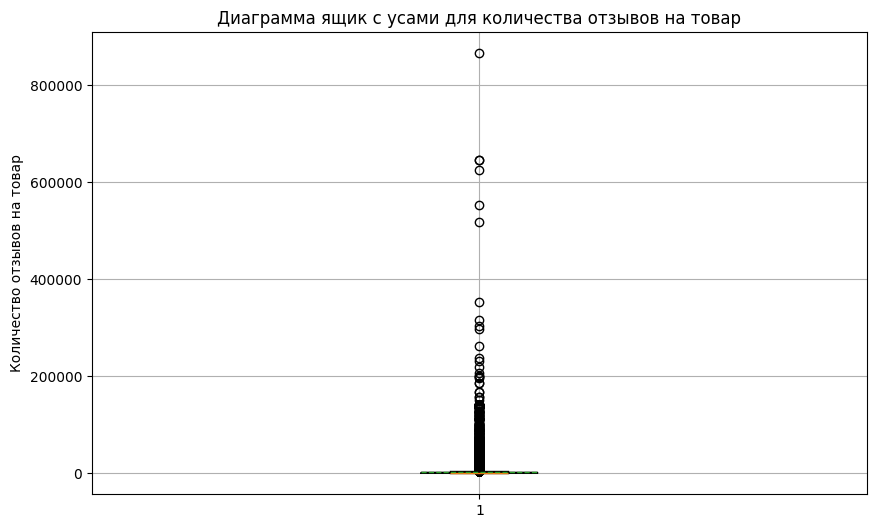

In [40]:
plt.figure(figsize=(10, 6))
plt.boxplot(filled_data[filled_data['Number_of_reviews'].notna()]['Number_of_reviews'],
            notch=True,
            vert=True,
            showmeans=True,
            meanline=True
            )
plt.title('Диаграмма ящик с усами для количества отзывов на товар')
plt.ylabel('Количество отзывов на товар')

plt.grid()
plt.show()

In [41]:
filled_data['Number_of_reviews'] = filled_data['Number_of_reviews'].fillna(np.nanmedian(filled_data['Number_of_reviews']))

Реализация функции по подсчету нижней и верхней границы данных для отбора выбросов

In [42]:
def IQR_bounds(vector: pd.Series) -> np.float64:
    IQR = vector.quantile(0.75) - vector.quantile(0.25)
    reviews_max = vector.quantile(0.75) + 1.5 * IQR
    reviews_min = vector.quantile(0.25) - 1.5 * IQR

    return (reviews_min, reviews_max)

In [43]:
reviews_min, reviews_max = IQR_bounds(filled_data['Number_of_reviews'])

In [44]:
f'Диапазон значений, не считающиеся выбросами: {(max(0, reviews_min), np.round(reviews_max, 2))}'

'Диапазон значений, не считающиеся выбросами: (0, np.float64(4437.75))'

In [45]:
f"Разница между верхней границей и максимальным значением столбца: {np.round(filled_data['Number_of_reviews'].max() / reviews_max * 100, 2)}%"

'Разница между верхней границей и максимальным значением столбца: 19505.33%'

In [46]:
rev_out = filled_data[filled_data['Number_of_reviews'] > reviews_max]['Number_of_reviews'].count()

f'Доля выбросов: {np.round(rev_out / len(filled_data) * 100, 2)}%'

'Доля выбросов: 13.86%'

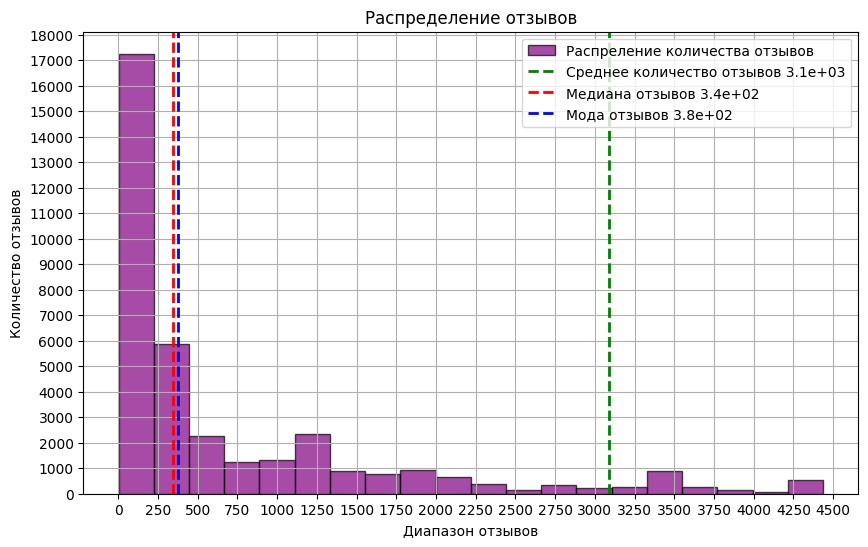

In [47]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(filled_data[filled_data['Number_of_reviews'] <= reviews_max]['Number_of_reviews'],
        bins=20,
        color='purple',
        edgecolor='black',
        alpha=0.7,
        label='Распреление количества отзывов')

ax.axvline(np.nanmean(data['Number_of_reviews']),
           color='green',
           linestyle='--',
           linewidth=2,
           label=f"Среднее количество отзывов {np.nanmean(data['Number_of_reviews']):.2}")

ax.axvline(np.nanmedian(data['Number_of_reviews']),
           color='red',
           linestyle='--',
           linewidth=2,
           label=f"Медиана отзывов {np.nanmedian(data['Number_of_reviews']):.2}")

ax.axvline(filled_data['Number_of_reviews'].sort_values(ascending=False)[0],
           color='blue',
           linestyle='--',
           linewidth=2,
           label=f"Мода отзывов {filled_data['Number_of_reviews'].sort_values(ascending=False)[0]:.2}")

ax.set_title('Распределение отзывов')
ax.set_xlabel('Диапазон отзывов')
ax.set_ylabel('Количество отзывов')

ax.xaxis.set_major_locator(ticker.MultipleLocator(250))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1000))


plt.legend()
plt.grid()
plt.show()

### Работа со столбцом: количество купленного товара за месяц (bought_over_then_in_last_month)

In [48]:
print(f"Среднее по покупкам за месяц: {np.round(np.nanmean(filled_data['bought_over_then_in_last_month']), 2)}\n\
Медиана по покупкам за месяц: {np.round(np.nanmedian(filled_data['bought_over_then_in_last_month']), 2)}\n\
Минимальное значение по покупкам за месяц: {np.nanmin(filled_data['bought_over_then_in_last_month'])}\n\
Максимальное значение по покупкам за месяц: {np.nanmax(filled_data['bought_over_then_in_last_month'])}")

Среднее по покупкам за месяц: 1293.67
Медиана по покупкам за месяц: 200.0
Минимальное значение по покупкам за месяц: 50.0
Максимальное значение по покупкам за месяц: 100000.0


In [49]:
boughts_min, boughts_max = IQR_bounds(filled_data['bought_over_then_in_last_month'])
f'Нижняя и верхняя границы по покупкам в месяц: {boughts_min, boughts_max}'

'Нижняя и верхняя границы по покупкам в месяц: (np.float64(-350.0), np.float64(850.0))'

In [50]:
boughts_outliers = filled_data[filled_data['bought_over_then_in_last_month'] > boughts_max]['bought_over_then_in_last_month'].count()
f"Доля выбросов по покупкам в месяц: {np.round(boughts_outliers / len(filled_data) * 100, 2)}%"

'Доля выбросов по покупкам в месяц: 10.57%'

In [51]:
from scipy.stats import kurtosis #Он же эксцесс

f"Эксцесс данных количества покупок за месяц: {np.round(kurtosis(filled_data[filled_data['bought_over_then_in_last_month'].notna()]['bought_over_then_in_last_month']), 2)}"

'Эксцесс данных количества покупок за месяц: 139.66'

In [52]:
filled_data['bought_over_then_in_last_month'] = filled_data['bought_over_then_in_last_month'].fillna(np.nanmedian(filled_data['bought_over_then_in_last_month']))

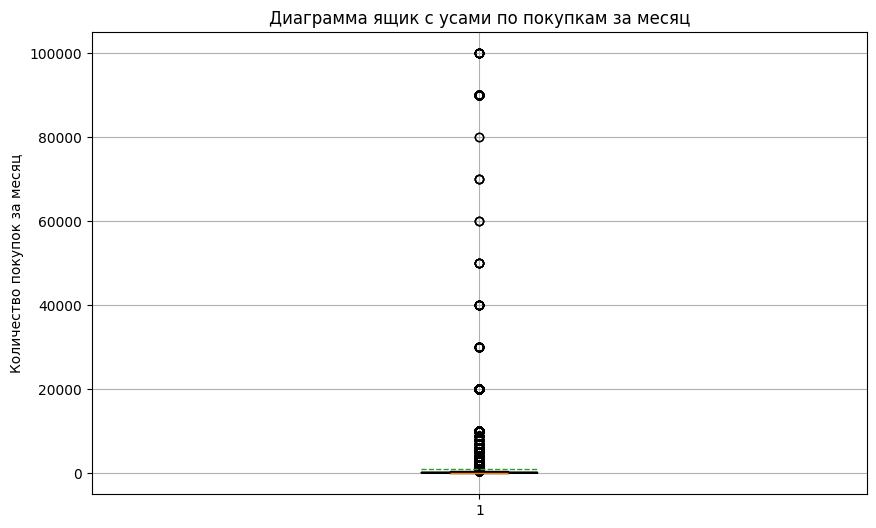

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(filled_data['bought_over_then_in_last_month'],
           patch_artist=True,       #Закрасить бокс
           notch=True,              #вырез для медианы
           vert=True,               #вертикальный график
           showmeans=True,          #показать среднее
           meanline=True            #среднее в виде линии
           )

ax.set_title('Диаграмма ящик с усами по покупкам за месяц')
ax.set_ylabel('Количество покупок за месяц')

plt.grid()
plt.show()

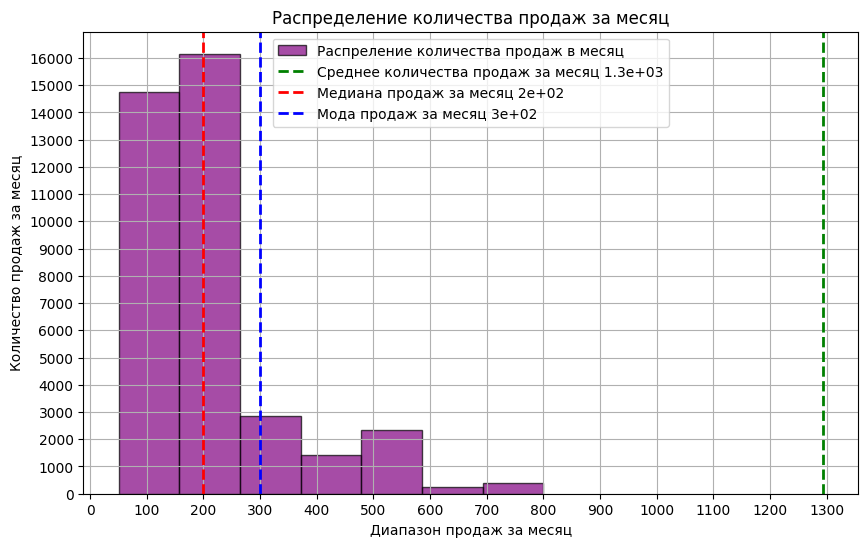

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(filled_data[filled_data['bought_over_then_in_last_month'] <= boughts_max]['bought_over_then_in_last_month'],
        bins=7,
        color='purple',
        edgecolor='black',
        alpha=0.7,
        label='Распреление количества продаж в месяц')

ax.axvline(np.nanmean(data['bought_over_then_in_last_month']),
           color='green',
           linestyle='--',
           linewidth=2,
           label=f"Среднее количества продаж за месяц {np.nanmean(data['bought_over_then_in_last_month']):.2}")

ax.axvline(np.nanmedian(data['bought_over_then_in_last_month']),
           color='red',
           linestyle='--',
           linewidth=2,
           label=f"Медиана продаж за месяц {np.nanmedian(data['bought_over_then_in_last_month']):.2}")

ax.axvline(filled_data['bought_over_then_in_last_month'].sort_values(ascending=False)[0],
           color='blue',
           linestyle='--',
           linewidth=2,
           label=f"Мода продаж за месяц {filled_data['bought_over_then_in_last_month'].sort_values(ascending=False)[0]:.2}")

ax.set_title('Распределение количества продаж за месяц')
ax.set_xlabel('Диапазон продаж за месяц')
ax.set_ylabel('Количество продаж за месяц')

ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1000))


plt.legend()
plt.grid()
plt.show()

### Работа со столбцом: текущая цена на товар(Current/discounted_price)

In [55]:
f"Эксцесс данных по текущей цене продукта: {np.round(kurtosis(filled_data[filled_data['Current/discounted_price'].notna()]['Current/discounted_price']), 2)}"

'Эксцесс данных по текущей цене продукта: 5.25'

In [56]:
print(f"Среднее по текущим ценам на товары: {np.round(np.nanmean(filled_data[filled_data['Current/discounted_price'].notna()]['Current/discounted_price']), 2)}\n\
Стандартное отклонение по текущим ценам на товары: {np.round(np.std(filled_data[filled_data['Current/discounted_price'].notna()]['Current/discounted_price']), 2)}")

Среднее по текущим ценам на товары: 147.6
Стандартное отклонение по текущим ценам на товары: 198.08


In [57]:
filled_data['Current/discounted_price'] = filled_data['Current/discounted_price'].fillna(np.nanmedian(filled_data['Current/discounted_price']))
filled_data['Current/discounted_price'].isna().sum()

np.int64(0)

In [58]:
cur_price_min, cur_price_max = IQR_bounds(filled_data['Current/discounted_price'])
print(f'Нижняя и верхняя границы для текущей цена на товары: {np.round(cur_price_min, 2), np.round(cur_price_max, 2)}')

Нижняя и верхняя границы для текущей цена на товары: (np.float64(-84.87), np.float64(242.91))


In [59]:
prices_outliers = filled_data[filled_data['Current/discounted_price'] > cur_price_max]['Current/discounted_price'].count()
f"Доля выбросов по покупкам в месяц: {np.round(prices_outliers / len(filled_data) * 100, 2)}%"

'Доля выбросов по покупкам в месяц: 12.65%'

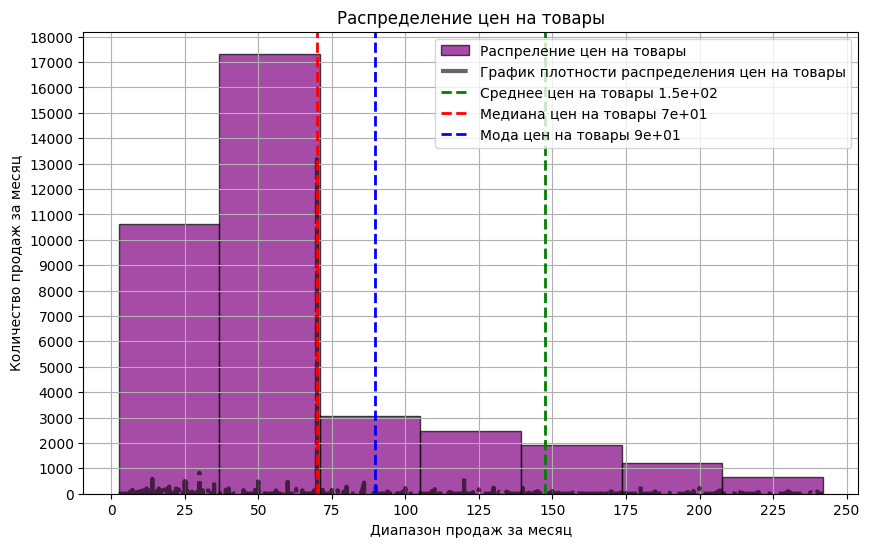

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(filled_data[filled_data['Current/discounted_price'] <= cur_price_max]['Current/discounted_price'],
        bins=7,
        color='purple',
        edgecolor='black',
        alpha=0.7,
        label='Распреление цен на товары')

ax.plot(filled_data[filled_data['Current/discounted_price'] <= cur_price_max]['Current/discounted_price'].value_counts().sort_index().index,
        filled_data[filled_data['Current/discounted_price'] <= cur_price_max]['Current/discounted_price'].value_counts().sort_index().values,
        color='black',
        linestyle='-.',
        linewidth=3,
        alpha=0.6,
        label='График плотности распределения цен на товары')

ax.axvline(np.nanmean(data['Current/discounted_price']),
           color='green',
           linestyle='--',
           linewidth=2,
           label=f"Среднее цен на товары {np.nanmean(data['Current/discounted_price']):.2}")

ax.axvline(np.nanmedian(data['Current/discounted_price']),
           color='red',
           linestyle='--',
           linewidth=2,
           label=f"Медиана цен на товары {np.nanmedian(data['Current/discounted_price']):.2}")

ax.axvline(filled_data['Current/discounted_price'].sort_values(ascending=False)[0],
           color='blue',
           linestyle='--',
           linewidth=2,
           label=f"Мода цен на товары {filled_data['Current/discounted_price'].sort_values(ascending=False)[0]:.2}")

ax.set_title('Распределение цен на товары')
ax.set_xlabel('Диапазон продаж за месяц')
ax.set_ylabel('Количество продаж за месяц')

ax.xaxis.set_major_locator(ticker.MultipleLocator(25))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1000))


plt.legend()
plt.grid()
plt.show()

In [61]:
filled_data['delivery_date'].value_counts()

delivery_date
2025-09-04    7582
2025-09-01    6189
2025-09-03    4832
2025-09-11    3710
2025-09-02    3338
2025-09-09    1420
2025-09-05     696
2025-09-08     421
2025-08-30     192
2025-08-28      90
2025-08-29      36
2025-09-10      10
2025-09-06       5
2025-09-12       2
2025-09-19       1
2025-09-15       1
2025-08-31       1
Name: count, dtype: int64

In [62]:
filled_data['delivery_date'] = filled_data['delivery_date'].fillna(filled_data['delivery_date'].sort_values(ascending=False)[0])
filled_data.isna().sum()

Title                                 0
Rating                             1024
Number_of_reviews                     0
bought_over_then_in_last_month        0
Current/discounted_price              0
Price_on_variant                      0
Listed_price, $                   31002
is_best_seller                        0
is_sponsored                          0
dollars_coupon                        0
discount_coupon                       0
is_available                          0
delivery_day_number                   0
delivery_date                         0
sustainability_badges                 0
collected_at                          0
dtype: int64

### Работа со столбцом: оригинальная цена (Listed_price, $)

In [63]:
filled_data['Listed_price, $'].value_counts()

Listed_price, $
79.99     500
29.99     406
16.61     360
23.26     283
43.99     241
         ... 
42.50       1
20.98       1
98.99       1
313.99      1
224.99      1
Name: count, Length: 864, dtype: int64

In [64]:
listed_nan_mean, listed_nan_std = np.nanmean(filled_data['Listed_price, $']), np.nanstd(filled_data['Listed_price, $'])
listed_nan_mean, listed_nan_std

(np.float64(123.76882720808705), np.float64(156.199981034744))

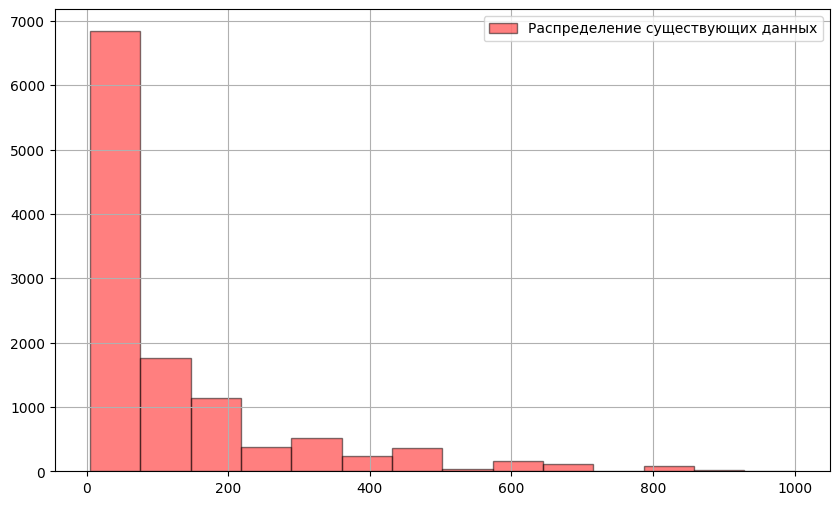

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(filled_data[filled_data['Listed_price, $'].notna()]['Listed_price, $'],
        bins=14,
        color='red',
        edgecolor='black',
        alpha=0.5,
        label='Распределение существующих данных')

ax.set_xlabel('')

plt.grid()
plt.legend()
plt.show()

In [66]:
rng = np.random.default_rng()       #Задали генератор
listed_price_samples = rng.exponential(scale=np.nanmean(filled_data['Listed_price, $']), size=len(filled_data[filled_data['Listed_price, $'].isna()]))
listed_price_samples = (listed_price_samples - np.mean(listed_price_samples)) / np.std(listed_price_samples)
listed_price_samples = listed_price_samples * listed_nan_std + listed_nan_mean
listed_price_samples

array([126.50779872,  -2.61395798, 125.69731224, ...,  67.48700342,
       138.76401873, -24.86535946])

In [67]:
filled_data['Listed_price, $'] = filled_data['Listed_price, $'].fillna(np.random.choice(listed_price_samples, replace=False))
filled_data['Listed_price, $'].isna().sum()

np.int64(0)

In [68]:
np.mean(filled_data['Listed_price, $']), np.std(filled_data['Listed_price, $'])

(np.float64(170.7975277925667), np.float64(86.64019179438883))

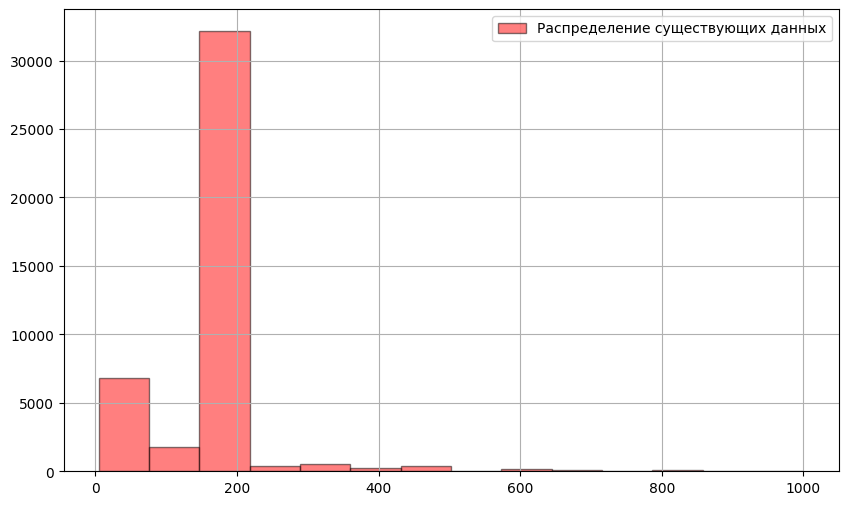

In [69]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(filled_data[filled_data['Listed_price, $'].notna()]['Listed_price, $'],
        bins=14,
        color='red',
        edgecolor='black',
        alpha=0.5,
        label='Распределение существующих данных')

ax.set_xlabel('')

plt.grid()
plt.legend()
plt.show()

In [70]:
filled_data.columns

Index(['Title', 'Rating', 'Number_of_reviews',
       'bought_over_then_in_last_month', 'Current/discounted_price',
       'Price_on_variant', 'Listed_price, $', 'is_best_seller', 'is_sponsored',
       'dollars_coupon', 'discount_coupon', 'is_available',
       'delivery_day_number', 'delivery_date', 'sustainability_badges',
       'collected_at'],
      dtype='object')

In [71]:
filled_data[['Rating', 'Number_of_reviews',
       'bought_over_then_in_last_month', 'Current/discounted_price',
       'Listed_price, $', 'is_best_seller', 'is_sponsored',
       'dollars_coupon', 'discount_coupon', 'is_available',
       'delivery_day_number', 'delivery_date', 'sustainability_badges',
       'collected_at']].corr()

,Rating,Number_of_reviews,bought_over_then_in_last_month,Current/discounted_price,"Listed_price, $",is_best_seller,is_sponsored,dollars_coupon,discount_coupon,is_available,delivery_day_number,delivery_date,sustainability_badges,collected_at
Rating,1.000000,0.099750,0.135210,-0.087161,-0.107581,0.027851,0.023373,-0.047120,0.006874,0.143505,0.062787,0.039368,-0.015025,-0.079078
Number_of_reviews,0.099750,1.000000,0.299165,-0.088388,-0.080497,0.191900,0.026264,-0.022182,-0.011417,0.022522,-0.021025,-0.064409,0.103624,-0.111894
bought_over_then_in_last_month,0.135210,0.299165,1.000000,-0.090221,-0.133892,0.117134,0.243242,-0.016524,-0.011200,0.088295,0.064797,0.004137,-0.009103,-0.060148
Current/discounted_price,-0.087161,-0.088388,-0.090221,1.000000,0.400395,-0.024771,0.020004,0.036968,-0.035479,0.159333,0.138313,0.023307,0.025058,0.055493
"Listed_price, $",-0.107581,-0.080497,-0.133892,0.400395,1.000000,-0.034653,-0.075139,0.046696,-0.023860,-0.105700,-0.139662,-0.123709,0.045836,0.003361
is_best_seller,0.027851,0.191900,0.117134,-0.024771,-0.034653,1.000000,0.007762,-0.008097,-0.003912,0.010747,-0.022466,-0.042566,0.002667,-0.074286
is_sponsored,0.023373,0.026264,0.243242,0.020004,-0.075139,0.007762,1.000000,0.064792,0.234431,0.258821,0.168754,0.129803,0.032820,-0.044448
dollars_coupon,-0.047120,-0.022182,-0.016524,0.036968,0.046696,-0.008097,0.064792,1.000000,-0.012859,0.074522,0.088226,0.041045,-0.022806,0.053775
discount_coupon,0.006874,-0.011417,-0.011200,-0.035479,-0.023860,-0.003912,0.234431,-0.012859,1.000000,0.083270,0.076314,0.091401,-0.029502,0.012963
is_available,0.143505,0.022522,0.088295,0.159333,-0.105700,0.010747,0.258821,0.074522,0.083270,1.000000,0.645294,0.425524,-0.018471,-0.011010


### Попытка реализации заполнения данными столбца оригинальная цена (Listed_price, $) из предположения о виде распределения

Так как в столбце более 67% пропущенных значений и он не несет в себе особой ценности (отсутствие корреляции с другими признаками исходного датасета), принято решение о его исключении из датасета. Была попытка воссоздать данные согласно экспоненциальному распределению по эмпирически посчитанному среднему (соответственно параметр lambda), но после заполнения пропусков сильно исказилось среднее и стандартное отклонение, а форма распределения приняла немного другой вид.

## Полностью очищенный датасет, подготовленный к дальнейшей с ним работе реализован и показан ниже

In [72]:
filled_data = filled_data.drop(columns=['Listed_price, $', 'Price_on_variant'])
filled_data.head(3)

,Title,Rating,Number_of_reviews,bought_over_then_in_last_month,Current/discounted_price,is_best_seller,is_sponsored,dollars_coupon,discount_coupon,is_available,delivery_day_number,delivery_date,sustainability_badges,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,0,1,0.0,0.15,1,1,2025-09-01,1,2025-08-21 11:14:00
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,0,1,0.0,0.00,1,5,2025-08-29,0,2025-08-21 11:14:00
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,0,1,0.0,0.00,1,1,2025-09-01,0,2025-08-21 11:14:00


In [73]:
filled_data.isna().sum()

Title                                0
Rating                            1024
Number_of_reviews                    0
bought_over_then_in_last_month       0
Current/discounted_price             0
is_best_seller                       0
is_sponsored                         0
dollars_coupon                       0
discount_coupon                      0
is_available                         0
delivery_day_number                  0
delivery_date                        0
sustainability_badges                0
collected_at                         0
dtype: int64

In [74]:
filled_data.dtypes

Title                                     object
Rating                                   float64
Number_of_reviews                        float64
bought_over_then_in_last_month           float64
Current/discounted_price                 float64
is_best_seller                             int32
is_sponsored                               int32
dollars_coupon                           float64
discount_coupon                          float64
is_available                               int64
delivery_day_number                        int32
delivery_date                     datetime64[ns]
sustainability_badges                      int64
collected_at                      datetime64[ns]
dtype: object

## ML-интеграция в заполнение данных

Признак Рейтинг (Rating) принят за целевую переменную, ml-модель взята RandomForestRegressor по нескольким причинам:

1. Сильные выбросы, разительно отличающиеся от среднего, RandomForest работает на основе рангов данных, что говорит нам о том, что нет особой необходимости масштабировать данные (StandardScaler, MinMaxScaler...)
2. Хорошо работает с категориальными данными после простого label-encoding
3. Улавливает нелинейные связи

In [75]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [76]:
filled_data_ml = filled_data.copy()

In [77]:
date_cols = filled_data_ml.select_dtypes(include=['datetime64']).columns.tolist()
print("Столбцы с датами:", date_cols)

for col in date_cols:

    filled_data_ml[f'{col}_year'] = filled_data_ml[col].dt.year
    filled_data_ml[f'{col}_month'] = filled_data_ml[col].dt.month
    filled_data_ml[f'{col}_day'] = filled_data_ml[col].dt.day
    
    filled_data_ml[f'{col}_dayofweek'] = filled_data_ml[col].dt.dayofweek

    filled_data_ml[f'{col}_dayofyear'] = filled_data_ml[col].dt.dayofyear

    filled_data_ml[f'{col}_week'] = filled_data_ml[col].dt.isocalendar().week.astype(int)

    filled_data_ml[f'{col}_quarter'] = filled_data_ml[col].dt.quarter

    filled_data_ml = filled_data_ml.drop(columns=[col])

print("\nОставшиеся datetime столбцы:", 
      filled_data_ml.select_dtypes(include=['datetime64']).columns.tolist())

Столбцы с датами: ['delivery_date', 'collected_at']

Оставшиеся datetime столбцы: []


In [78]:
X_filled, y_filled = filled_data_ml[filled_data_ml['Rating'].notna()].drop(columns=['Title', 'Rating']), \
                     filled_data_ml[filled_data_ml['Rating'].notna()]['Rating']

X_filled.shape, y_filled.shape

((41651, 24), (41651,))

In [79]:
filled_data_ml.head(3)

,Title,Rating,Number_of_reviews,bought_over_then_in_last_month,Current/discounted_price,is_best_seller,is_sponsored,dollars_coupon,discount_coupon,is_available,...,delivery_date_dayofyear,delivery_date_week,delivery_date_quarter,collected_at_year,collected_at_month,collected_at_day,collected_at_dayofweek,collected_at_dayofyear,collected_at_week,collected_at_quarter
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,0,1,0.0,0.15,1,...,244,36,3,2025,8,21,3,233,34,3
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,0,1,0.0,0.00,1,...,241,35,3,2025,8,21,3,233,34,3
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,0,1,0.0,0.00,1,...,244,36,3,2025,8,21,3,233,34,3


In [80]:
X_filled_train, X_filled_test, y_filled_train, y_filled_test = train_test_split(X_filled, 
                                                                                y_filled, 
                                                                                test_size=0.2, 
                                                                                random_state=42)

X_filled_train.shape, X_filled_test.shape, y_filled_train.shape, y_filled_test.shape

((33320, 24), (8331, 24), (33320,), (8331,))

In [81]:
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_filled_train, y_filled_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

Метрика Score на обучающих данных

In [82]:
model.score(X_filled_train, y_filled_train)

0.9643737273682704

Метрика Score на обучаемых данных

In [83]:
model.score(X_filled_test, y_filled_test)

0.8744496755204767

In [84]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def get_regression_metrics(y_true, y_pred):
    """Возвращает DataFrame с основными метриками регрессии"""
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_true, y_pred)
    
    metrics = {
        'MAE (Средняя абсолютная ошибка)': mae,
        'MSE (Среднеквадратичная ошибка)': mse,
        'RMSE (Корень из MSE)': rmse,
        'R_2 (Коэффициент детерминации)': r2
    }
    
    df_metrics = pd.DataFrame(list(metrics.items()), columns=['Метрика', 'Значение'])
    df_metrics['Значение'] = df_metrics['Значение'].apply(lambda x: f"{x:,.2f}" if isinstance(x, float) else x)
    
    return df_metrics

In [85]:
metrics_table_reg = get_regression_metrics(y_filled_test, model.predict(X_filled_test))
display(metrics_table_reg)

,Метрика,Значение
0,MAE (Средняя абсолютная ошибка),0.05
1,MSE (Среднеквадратичная ошибка),0.02
2,RMSE (Корень из MSE),0.13
3,R_2 (Коэффициент детерминации),0.87


Исходя из полученных метрик можно сделать вывод, что модель получает достаточно точные значения

In [86]:
mask = filled_data_ml['Rating'].isna()

X_miss = filled_data_ml.loc[mask].drop(columns=['Title', 'Rating'])

y_miss_pred = model.predict(X_miss)

filled_data.loc[mask, 'Rating'] = y_miss_pred

In [87]:
filled_data.head(3)

,Title,Rating,Number_of_reviews,bought_over_then_in_last_month,Current/discounted_price,is_best_seller,is_sponsored,dollars_coupon,discount_coupon,is_available,delivery_day_number,delivery_date,sustainability_badges,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,0,1,0.0,0.15,1,1,2025-09-01,1,2025-08-21 11:14:00
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,0,1,0.0,0.00,1,5,2025-08-29,0,2025-08-21 11:14:00
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,0,1,0.0,0.00,1,1,2025-09-01,0,2025-08-21 11:14:00


In [88]:
filled_data.isna().sum()

Title                             0
Rating                            0
Number_of_reviews                 0
bought_over_then_in_last_month    0
Current/discounted_price          0
is_best_seller                    0
is_sponsored                      0
dollars_coupon                    0
discount_coupon                   0
is_available                      0
delivery_day_number               0
delivery_date                     0
sustainability_badges             0
collected_at                      0
dtype: int64

## Метрики

Estimated_monthly_revenue или ожидаемая месячная выручка - метрика, показывающая минимальный прирост средств от продажи товаров по текущей цене товара

In [89]:
filled_data['estimated_monthly_revenue'] = filled_data['bought_over_then_in_last_month'] * \
                                           filled_data['Current/discounted_price']

Discount_lost_revenue - метрика, показывающая упущенную прибыль от скидок на товары с учетом купонов

In [90]:
filled_data['discount_lost_revenue'] = filled_data['Current/discounted_price'] * \
                                       filled_data['discount_coupon'] + filled_data['dollars_coupon']

Effective_price или эффективная цена - метрика, показывающая, сколько стоит товар с учетом скидок от купонов

In [91]:
filled_data['effective_price'] = filled_data['Current/discounted_price'] * \
                                 (1 - filled_data['discount_coupon']) - filled_data['dollars_coupon']

In [92]:
filled_data.head(3)

,Title,Rating,Number_of_reviews,bought_over_then_in_last_month,Current/discounted_price,is_best_seller,is_sponsored,dollars_coupon,discount_coupon,is_available,delivery_day_number,delivery_date,sustainability_badges,collected_at,estimated_monthly_revenue,discount_lost_revenue,effective_price
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,0,1,0.0,0.15,1,1,2025-09-01,1,2025-08-21 11:14:00,26904.0,13.452,76.228
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,0,1,0.0,0.00,1,5,2025-08-29,0,2025-08-21 11:14:00,59940.0,0.000,9.990
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,0,1,0.0,0.00,1,1,2025-09-01,0,2025-08-21 11:14:00,628000.0,0.000,314.000


## Агрегирующие метрики

In [98]:
total_monthly_revenue = np.round(filled_data['estimated_monthly_revenue'].sum(), 2)
print(f"Примерная выручка с продаж Amazon за август 2025 года: {total_monthly_revenue}$")


Примерная выручка с продаж Amazon за август 2025 года: 1837041150.0$


In [102]:
avg_sales_sponsored = filled_data[filled_data['is_sponsored'] == 1]['bought_over_then_in_last_month'].mean()
avg_sales_organic = filled_data[filled_data['is_sponsored'] == 0]['bought_over_then_in_last_month'].mean()

sponsored_lift = np.round(((avg_sales_sponsored / avg_sales_organic) - 1) * 100, 2) if avg_sales_organic > 0 else 0.0

print(f"Отношение количества проданных спонсируемых товаров к не спонсируемым: {sponsored_lift}%")

Отношение количества проданных спонсируемых товаров к не спонсируемым: 839.42%


In [108]:
has_dollar_coupon = filled_data['dollars_coupon'] > 0
has_discount_coupon = filled_data['discount_coupon'] > 0
avg_sales_with_coupon = filled_data[has_dollar_coupon | has_discount_coupon]['bought_over_then_in_last_month'].mean()
avg_sales_without_coupon = filled_data[~(has_dollar_coupon | has_discount_coupon)]['bought_over_then_in_last_month'].mean()

coupon_effectiveness = np.round(avg_sales_with_coupon / avg_sales_without_coupon, 2)\
                       if avg_sales_without_coupon > 0 else 0.0

print(f"Соотношение среднего количетсва купленных товаров с купонами к покупкам без купона: {coupon_effectiveness}")

Соотношение среднего количетсва купленных товаров с купонами к покупкам без купона: 0.5
